In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, r2_score


In [ ]:
df = pd.read_csv("/content/powerconsumption.csv")
df.head()


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])


In [ ]:
df['hour'] = df['Datetime'].dt.hour
df['day'] = df['Datetime'].dt.day
df['month'] = df['Datetime'].dt.month


In [ ]:
X = df[['Temperature', 'Humidity', 'hour', 'day', 'month']]

zones = [
    'PowerConsumption_Zone1',
    'PowerConsumption_Zone2',
    'PowerConsumption_Zone3'
]


In [ ]:
models = {}
results = {}

for zone in zones:
    print(f"\nTraining model for {zone}")

    y = df[zone]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    models[zone] = model
    results[zone] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

    print("MAE:", results[zone]["MAE"])
    print("R²:", results[zone]["R2"])



Training model for PowerConsumption_Zone1
MAE: 626.6434158065781
R²: 0.9817303995711869

Training model for PowerConsumption_Zone2
MAE: 440.6954506512106
R²: 0.9831209632817773

Training model for PowerConsumption_Zone3
MAE: 376.48650810350927
R²: 0.9909647239364531


In [ ]:
results_df = pd.DataFrame(results).T
results_df


,MAE,R2
PowerConsumption_Zone1,626.643416,0.981730
PowerConsumption_Zone2,440.695451,0.983121
PowerConsumption_Zone3,376.486508,0.990965


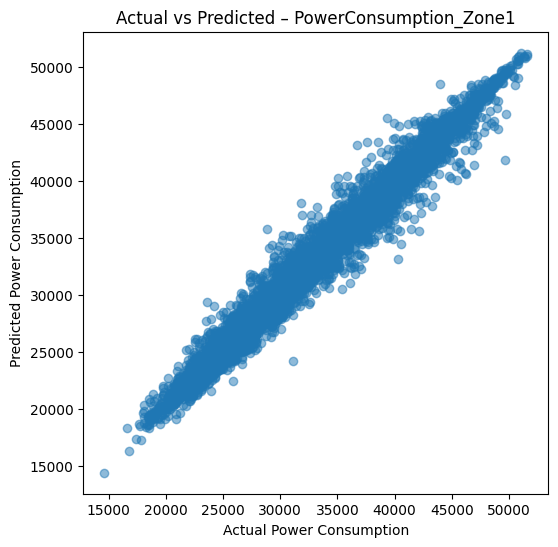

In [ ]:
zone = 'PowerConsumption_Zone1'

y = df[zone]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred = models[zone].predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Power Consumption")
plt.ylabel("Predicted Power Consumption")
plt.title(f"Actual vs Predicted – {zone}")
plt.show()


In [ ]:
anomaly_features = df[['PowerConsumption_Zone1']]

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

df['anomaly'] = iso.fit_predict(anomaly_features)
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})


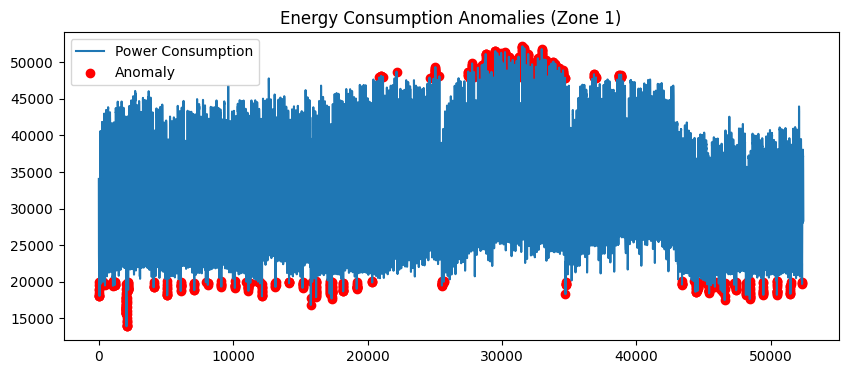

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df['PowerConsumption_Zone1'], label="Power Consumption")
plt.scatter(
    df.index[df['anomaly'] == 1],
    df['PowerConsumption_Zone1'][df['anomaly'] == 1],
    color='red',
    label="Anomaly"
)
plt.legend()
plt.title("Energy Consumption Anomalies (Zone 1)")
plt.show()


In [ ]:
zone = 'PowerConsumption_Zone1'

y = df[zone]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred = models[zone].predict(X_test)

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Error': y_test.values - y_pred
})

comparison.head(10)


,Actual,Predicted,Error
0,32985.14532,33012.922284,-27.776964
1,34737.64259,36376.146009,-1638.503419
2,27894.68354,28926.997899,-1032.314359
3,42476.93617,42675.405560,-198.469390
4,21341.14101,21410.196213,-69.055203
5,22043.54430,21448.222785,595.321515
6,32509.83051,33335.342595,-825.512085
7,21390.68852,21715.137049,-324.448529
8,37286.69202,38695.787071,-1409.095051
9,24966.29508,24426.428851,539.866229


In [ ]:
from sklearn.model_selection import train_test_split

def show_zone_output(zone, n_rows=10):
    y = df[zone]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    y_pred = models[zone].predict(X_test)

    output = pd.DataFrame({
        'Datetime': df.loc[y_test.index, 'Datetime'],
        f'Actual Power ({zone})': y_test.values,
        f'Predicted Power ({zone})': y_pred
    })

    print(f"\n{'='*15} {zone.upper()} OUTPUT {'='*15}\n")
    print(output.head(n_rows).to_string(index=True))


# 🔹 Show output for all zones
for zone in zones:
    show_zone_output(zone, n_rows=10)



=============== POWERCONSUMPTION_ZONE1 OUTPUT ===============

                 Datetime  Actual Power (PowerConsumption_Zone1)  Predicted Power (PowerConsumption_Zone1)
15506 2017-04-18 16:20:00                            32985.14532                              33012.922284
51943 2017-12-27 17:10:00                            34737.64259                              36376.146009
212   2017-01-02 11:20:00                            27894.68354                              28926.997899
11210 2017-03-19 20:20:00                            42476.93617                              42675.405560
16307 2017-04-24 05:50:00                            21341.14101                              21410.196213
1165  2017-01-09 02:10:00                            22043.54430                              21448.222785
4962  2017-02-04 11:00:00                            32509.83051                              33335.342595
21489 2017-05-30 05:30:00                            21390.68852                

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---- Take user inputs ----
temp = float(input("Enter Temperature: "))
humidity = float(input("Enter Humidity: "))
hour = int(input("Enter Hour (0-23): "))
day = int(input("Enter Day (1-31): "))
month = int(input("Enter Month (1-12): "))

# ---- Create input dataframe ----
new_data = pd.DataFrame({
    'Temperature': [temp],
    'Humidity': [humidity],
    'hour': [hour],
    'day': [day],
    'month': [month]
})

# ---- Predict power consumption ----
predictions = {
    'Zone 1': models['PowerConsumption_Zone1'].predict(new_data)[0],
    'Zone 2': models['PowerConsumption_Zone2'].predict(new_data)[0],
    'Zone 3': models['PowerConsumption_Zone3'].predict(new_data)[0]
}

print("\nPredicted Power Consumption")
for z, v in predictions.items():
    print(f"{z}: {round(v, 2)}")

# ---- Dropdown ----
zone_dropdown = widgets.Dropdown(
    options=['Zone 1', 'Zone 2', 'Zone 3'],
    description='Select Zone:'
)

output = widgets.Output()

display(zone_dropdown)
display(output)

# ---- Anomaly check ----
def check_anomaly(change):
    with output:
        clear_output(wait=True)

        zone = change['new']
        value = predictions[zone]

        anomaly = iso.predict(
            pd.DataFrame({'PowerConsumption_Zone1': [value]})
        )[0]

        status = "ANOMALY" if anomaly == -1 else "NORMAL"
        print(f"Anomaly Status for {zone}: {status}")

zone_dropdown.observe(check_anomaly, names='value')


Enter Temperature: 25
Enter Humidity: 100
Enter Hour (0-23): 5
Enter Day (1-31): 3
Enter Month (1-12): 11

Predicted Power Consumption
Zone 1: 22986.15
Zone 2: 16543.1
Zone 3: 11303.8


Dropdown(description='Select Zone:', options=('Zone 1', 'Zone 2', 'Zone 3'), value='Zone 1')

Output()

In [ ]:
# Ask user for zone selection
zone_input = input("Select Zone (1 / 2 / 3): ").strip()

zone_map = {
    "1": "PowerConsumption_Zone1",
    "2": "PowerConsumption_Zone2",
    "3": "PowerConsumption_Zone3"
}

if zone_input not in zone_map:
    raise ValueError("Invalid zone selected. Please enter 1, 2, or 3.")

zone = zone_map[zone_input]
print(f"\nSelected Zone: {zone}")


Select Zone (1 / 2 / 3): 2

Selected Zone: PowerConsumption_Zone2


In [ ]:
# Ensure hour column exists
df['hour'] = df['Datetime'].dt.hour

# Hourly average power consumption
hourly_avg = df.groupby('hour')[zone].mean()


In [ ]:
low_energy_hours = hourly_avg.sort_values().head(5)

print("\nLowest Energy Consumption Hours:")
low_energy_hours



Lowest Energy Consumption Hours:


,PowerConsumption_Zone2
hour,
6,14934.698604
5,14974.907723
4,15624.081077
7,15719.115067
3,16052.585288


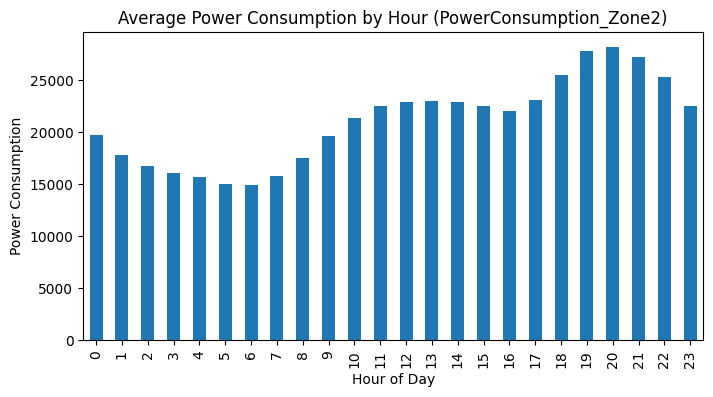

In [ ]:
plt.figure(figsize=(8,4))
hourly_avg.plot(kind='bar')
plt.title(f"Average Power Consumption by Hour ({zone})")
plt.xlabel("Hour of Day")
plt.ylabel("Power Consumption")
plt.show()


In [ ]:
# Ensure hour column exists
df['hour'] = df['Datetime'].dt.hour

# Hourly average for selected zone
hourly_avg = df.groupby('hour')[zone].mean()


In [ ]:
hourly_values = hourly_avg.reset_index()
hourly_values.columns = ['Hour', f'Average_Power_{zone}']

hourly_values


,Hour,Average_Power_PowerConsumption_Zone2
0,0,19692.073550
1,1,17765.078949
2,2,16730.156092
3,3,16052.585288
4,4,15624.081077
5,5,14974.907723
6,6,14934.698604
7,7,15719.115067
8,8,17529.678454
9,9,19640.721504


In [ ]:
df['hour'] = df['Datetime'].dt.hour

hourly_avg = df.groupby('hour')[zone].mean()
hourly_table = hourly_avg.reset_index()
hourly_table.columns = ['Hour', 'Average_Power']


In [ ]:
recommended_hours = hourly_table.sort_values('Average_Power').head(5)

print("\nRecommended Low-Energy Operating Hours:")
for _, row in recommended_hours.iterrows():
    print(f"Hour {int(row['Hour'])}: Avg Power ≈ {row['Average_Power']:.2f}")



Recommended Low-Energy Operating Hours:
Hour 6: Avg Power ≈ 14934.70
Hour 5: Avg Power ≈ 14974.91
Hour 4: Avg Power ≈ 15624.08
Hour 7: Avg Power ≈ 15719.12
Hour 3: Avg Power ≈ 16052.59
